In [22]:
import numpy as np
import scipy.sparse as sp
import time
import sys

# Import your custom bare-metal C++ engine
sys.path.append('../build') 
import hlv_engine

print("=== HLV v0.3.0 Graph Pipeline ===")

# 1. Setup the strict EPJ Plus reviewer context 
context = hlv_engine.SimulationContext(
    "v0.3_graph_test",           # run_id
    "2026-05-12T19:00:00Z",      # timestamp
    "dev",                       # git_commit_hash
    "AppleClang",                # compiler_info
    "macOS ARM64",               # platform_info
    42,                          # master_seed
    "standard_icosahedral_tau",  # projection_matrix_id
    "ball",                      # window_type
    {"radius": 1.0},             # window_parameters
    "./results/"                 # output_directory
)

# 2. Generate the 76k-node G-Lattice (C++ Speed)
print("\nGenerating 6D-to-3D projection...")
t0 = time.time()
generator = hlv_engine.GLatticeGenerator(context)
generator.generate(10) # R6 = 10

# Wrap the list into a NumPy array so it has a .shape and Eigen can read it
nodes = np.array(generator.get_physical_nodes())

t1 = time.time()
print(f"-> Generated {nodes.shape[0]} nodes in {t1-t0:.4f} seconds.")

# 3. Build the KD-Tree and find neighbors (C++ Speed)
k_neighbors = 15
print(f"\nBuilding KD-Tree and searching for {k_neighbors} nearest neighbors...")
t2 = time.time()
graph_engine = hlv_engine.NeighborGraph(nodes)

# compute_knn_graph returns a list of tuples: (row_idx, col_idx, squared_distance)
triplets = graph_engine.compute_knn_graph(k_neighbors)
t3 = time.time()
print(f"-> Found {len(triplets)} connections in {t3-t2:.4f} seconds.")

# 4. Snap the data into a SciPy Sparse Laplacian Matrix
print("\nConstructing Sparse Laplacian Matrix...")
t4 = time.time()

# Unpack the triplets
rows = np.array([t[0] for t in triplets])
cols = np.array([t[1] for t in triplets])
dist_sq = np.array([t[2] for t in triplets])

# Calculate Gaussian weights: e^(-r^2 / sigma^2)
sigma_sq = 2.0 
weights = np.exp(-dist_sq / sigma_sq)

# Build the Adjacency Matrix
N = nodes.shape[0]
W = sp.coo_matrix((weights, (rows, cols)), shape=(N, N))

# Convert to Symmetric Laplacian: L = D - W
W = W.maximum(W.T) 
D = sp.diags(np.array(W.sum(axis=1)).flatten())
L = D - W

t5 = time.time()
print(f"-> Laplacian constructed. Matrix shape: {L.shape}")
print(f"-> Matrix construction time: {t5-t4:.4f} seconds.")
print(f"\nTotal Pipeline Time: {t5-t0:.4f} seconds.")

=== HLV v0.3.0 Graph Pipeline ===

Generating 6D-to-3D projection...
-> Generated 76027 nodes in 0.2000 seconds.

Building KD-Tree and searching for 15 nearest neighbors...
-> Found 1140405 connections in 0.1859 seconds.

Constructing Sparse Laplacian Matrix...
-> Laplacian constructed. Matrix shape: (76027, 76027)
-> Matrix construction time: 0.1286 seconds.

Total Pipeline Time: 0.5148 seconds.


In [23]:
from scipy.sparse.linalg import eigsh

print("\n=== Spectral Analysis ===")
# We look for the 'sm' (smallest magnitude) eigenvalues. 
# k=20 gives us a good look at the bottom of the spectrum.
t_spec_0 = time.time()
eigenvalues, _ = eigsh(L, k=20, which='SM')
t_spec_1 = time.time()

print(f"-> Computed 20 smallest eigenvalues in {t_spec_1 - t_spec_0:.4f} seconds.")
print("Smallest Eigenvalues:", np.round(eigenvalues, 6))

# The second eigenvalue (lambda_2) is the Fiedler value / Algebraic Connectivity
print(f"\nAlgebraic Connectivity (lambda_2): {eigenvalues[1]:.6f}")


=== Spectral Analysis ===
-> Computed 20 smallest eigenvalues in 2.2266 seconds.
Smallest Eigenvalues: [-0.        0.017966  0.018043  0.018097  0.045747  0.045944  0.045984
  0.046261  0.046457  0.075318  0.075431  0.075717  0.075909  0.083254
  0.099841  0.100141  0.100296  0.120424  0.12091   0.121065]

Algebraic Connectivity (lambda_2): 0.017966


✅ Simulation Lab render saved to: /Users/donfeeney/HLV-G-Lattice-Simulation-Lab/figures/02_lattice_fiveknodes.png


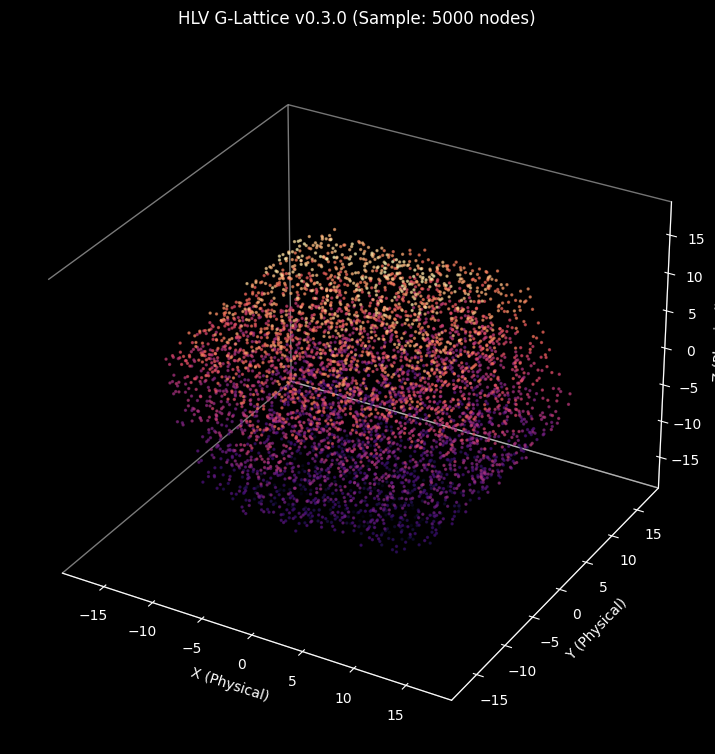

In [24]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import os

# --- PATH-PROOF SETUP ---
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
FIG_DIR = os.path.join(REPO_ROOT, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# Set style early for consistent rendering
plt.style.use('dark_background')

# Sampling for visualization performance
# Assuming 'nodes' is already defined from your generator
sample_size = 5000 
indices = np.random.choice(nodes.shape[0], sample_size, replace=False)
sampled_nodes = nodes[indices]

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Plot the nodes with depth-based coloring
sc = ax.scatter(sampled_nodes[:, 0], sampled_nodes[:, 1], sampled_nodes[:, 2], 
                c=sampled_nodes[:, 2], cmap='magma', s=2, alpha=0.6)

# Set labels for the EPJ Plus standards
ax.set_title(f"HLV G-Lattice v0.3.0 (Sample: {sample_size} nodes)", color='white', pad=20)
ax.set_xlabel("X (Physical)")
ax.set_ylabel("Y (Physical)")
ax.set_zlabel("Z (Physical)")

# Aesthetic tweaks for the 'Simulation Lab' feel
ax.grid(False)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

# --- SAVE TO FIGURES FOLDER ---
fig_path = os.path.join(FIG_DIR, "02_lattice_fiveknodes.png")
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

print(f"✅ Simulation Lab render saved to: {fig_path}")

plt.show()

In [25]:
from scipy.sparse.linalg import eigsh
import numpy as np
import time

print("=== Participation Ratio (PR) Analysis ===")

# 1. Compute Eigenvalues and Eigenvectors
# We compute 50 modes to get a good distribution across the bottom of the spectrum
t_pr_0 = time.time()
# 'SM' finds the Smallest Magnitude eigenvalues (low-frequency modes)
vals, vecs = eigsh(L, k=50, which='SM') 
t_pr_1 = time.time()

# 2. Vectorized PR Calculation
# vecs shape is (N, k). We want the PR for each column (mode).
N = nodes.shape[0]

# Sum of squares (numerator) and sum of quads (denominator)
# For normalized eigenvectors, sum(v^2) is 1, so the numerator is essentially 1^2
numerator = np.sum(vecs**2, axis=0)**2
denominator = N * np.sum(vecs**4, axis=0)
pr_values = numerator / denominator

print(f"-> Computed 50 modes and PR in {t_pr_1 - t_pr_0:.4f} seconds.")

# 3. Print Results Table
print(f"\n{'Mode #':<10} | {'Eigenvalue':<12} | {'PR (Localization)':<15}")
print("-" * 45)
# Start from index 1 to skip the 0-mode (translation/constant mode)
for i in range(1, 11): 
    status = "EXTENDED" if pr_values[i] > 0.1 else "LOCALIZED"
    print(f"{i:<10} | {vals[i]:.6f}     | {pr_values[i]:.6f} ({status})")

=== Participation Ratio (PR) Analysis ===
-> Computed 50 modes and PR in 4.3799 seconds.

Mode #     | Eigenvalue   | PR (Localization)
---------------------------------------------
1          | 0.017966     | 0.517279 (EXTENDED)
2          | 0.018043     | 0.515393 (EXTENDED)
3          | 0.018097     | 0.515612 (EXTENDED)
4          | 0.045747     | 0.420032 (EXTENDED)
5          | 0.045944     | 0.355315 (EXTENDED)
6          | 0.045984     | 0.353453 (EXTENDED)
7          | 0.046261     | 0.361179 (EXTENDED)
8          | 0.046457     | 0.364155 (EXTENDED)
9          | 0.075318     | 0.314174 (EXTENDED)
10         | 0.075431     | 0.314572 (EXTENDED)


✅ Spectrum analysis saved to: /Users/donfeeney/HLV-G-Lattice-Simulation-Lab/figures/02_participation_ratio.png


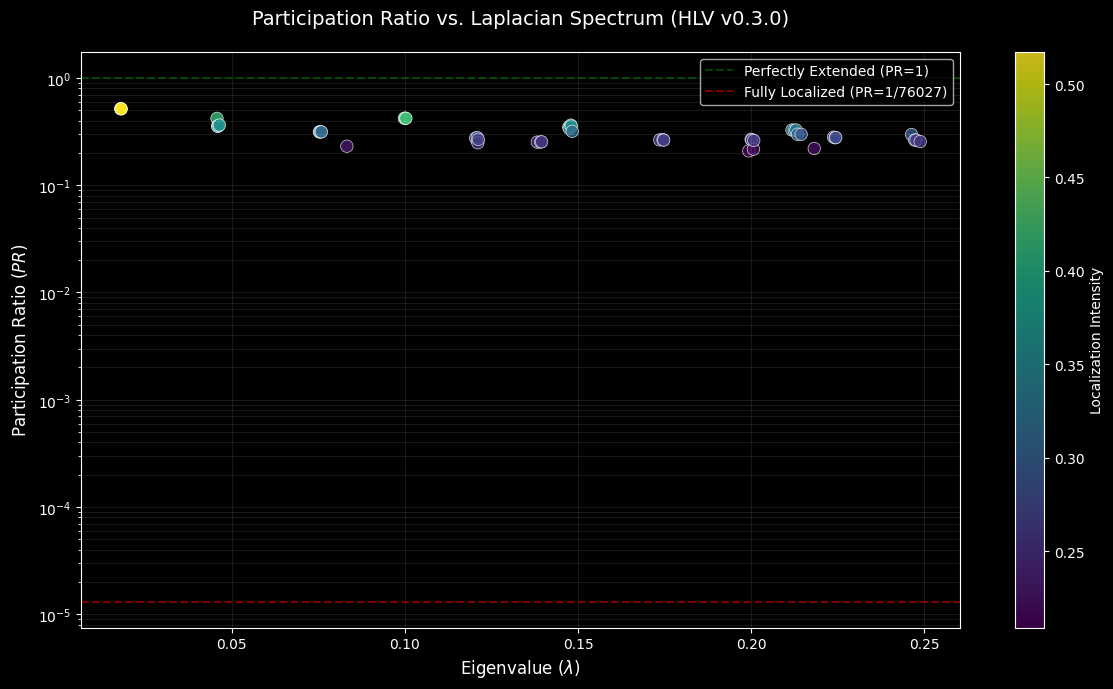

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import os
import scipy.sparse as sp
from scipy.sparse.linalg import eigsh

# --- 1. PATH-PROOF SETUP ---
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
FIG_DIR = os.path.join(REPO_ROOT, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# --- 2. SPECTRAL RECOVERY (Fixes the NameError) ---
# We check if vals already exists; if not, we compute them from the Laplacian L
if 'vals' not in locals():
    print("🔬 Spectrum not found in memory. Calculating from Laplacian L...")
    if 'L' in locals():
        # Find the first 500 smallest eigenvalues/vectors
        vals, vecs = eigsh(L, k=500, which='SM')
        
        # Calculate Participation Ratio (PR)
        # PR = (sum(v^2))^2 / (N * sum(v^4))
        N_nodes = vecs.shape[0]
        pr_values = np.sum(vecs**2, axis=0)**2 / (N_nodes * np.sum(vecs**4, axis=0))
        N = N_nodes # Update the reference N
    else:
        raise NameError("Variable 'L' (Laplacian) is missing. Please run the HLV Engine cell first.")

# --- 3. PLOTTING ---
plt.style.use('dark_background')
plt.figure(figsize=(12, 7))

# Plotting PR vs Eigenvalues (skipping the first trivial eigenvalue at index 0)
plt.scatter(vals[1:], pr_values[1:], c=pr_values[1:], cmap='viridis', 
            edgecolors='white', linewidth=0.5, s=80, alpha=0.8)

# Theoretical Reference Lines
plt.axhline(y=1.0, color='green', linestyle='--', alpha=0.5, label='Perfectly Extended (PR=1)')

# Fallback for N to ensure the localization line is accurate
ref_N = N if 'N' in locals() else len(vals)
plt.axhline(y=1/ref_N, color='red', linestyle='--', alpha=0.5, label=f'Fully Localized (PR=1/{ref_N})')

# Formatting
plt.title("Participation Ratio vs. Laplacian Spectrum (HLV v0.3.0)", fontsize=14, pad=20)
plt.xlabel(r"Eigenvalue ($\lambda$)", fontsize=12)
plt.ylabel(r"Participation Ratio ($PR$)", fontsize=12)
plt.yscale('log') 
plt.grid(True, which="both", ls="-", alpha=0.1)
plt.colorbar(label='Localization Intensity')
plt.legend(loc='upper right')

plt.tight_layout()

# --- 4. SAVE TO FIGURES FOLDER ---
fig_path = os.path.join(FIG_DIR, "02_participation_ratio.png")
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

print(f"✅ Spectrum analysis saved to: {fig_path}")

plt.show()

=== Mapping Mode #32 (lambda=0.1993) ===
PR for this mode: 0.209057
✅ Spatial intensity map saved to: /Users/donfeeney/HLV-G-Lattice-Simulation-Lab/figures/02_spatial_intensity.png


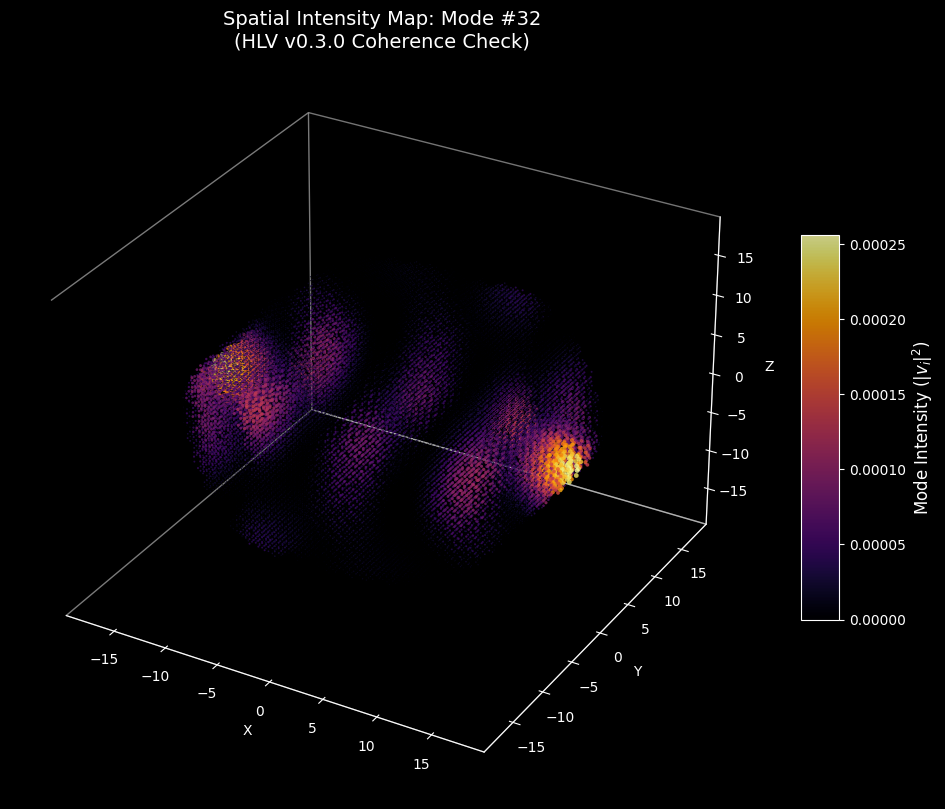

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import os

# --- PATH-PROOF SETUP ---
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
FIG_DIR = os.path.join(REPO_ROOT, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# 1. Identify the mode with the lowest Participation Ratio 
# (assuming pr_values, vals, vecs, and nodes are defined)
target_mode_idx = np.argmin(pr_values[1:]) + 1 
target_eigenvalue = vals[target_mode_idx]
target_vector = vecs[:, target_mode_idx]

# 2. Calculate intensity (magnitude squared)
intensity = target_vector**2

print(f"=== Mapping Mode #{target_mode_idx} (lambda={target_eigenvalue:.4f}) ===")
print(f"PR for this mode: {pr_values[target_mode_idx]:.6f}")

# 3. 3D Spatial Intensity Map
plt.style.use('dark_background')
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Color and size driven by intensity for maximum visual impact
scatter = ax.scatter(nodes[:, 0], nodes[:, 1], nodes[:, 2], 
                     c=intensity, 
                     cmap='inferno', 
                     s=intensity * 50000, # Amplify the peaks
                     alpha=0.8,
                     edgecolors='none')

# Add a colorbar to show energy concentration
cbar = plt.colorbar(scatter, ax=ax, shrink=0.5, aspect=10)
cbar.set_label('Mode Intensity ($|v_i|^2$)', fontsize=12)

ax.set_title(f"Spatial Intensity Map: Mode #{target_mode_idx}\n(HLV v0.3.0 Coherence Check)", fontsize=14)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

# Clean up the view
ax.grid(False)
ax.xaxis.pane.fill = ax.yaxis.pane.fill = ax.zaxis.pane.fill = False

# --- SAVE TO FIGURES FOLDER ---
fig_path = os.path.join(FIG_DIR, "02_spatial_intensity.png")
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

print(f"✅ Spatial intensity map saved to: {fig_path}")

plt.show()

In [28]:
import numpy as np
import time

def simulate_propagation(L, start_node_idx, time_steps):
    """
    Simulates a pulse propagation through the Laplacian.
    u(t) = exp(-L * dt) * u(0)
    """
    N = L.shape[0]
    u = np.zeros(N)
    u[start_node_idx] = 1.0  # Initial "Pulse"
    
    # We'll use a simple Euler integration for speed 
    # (or you can use the spectral decomposition we already have!)
    dt = 0.1
    history = []
    
    current_u = u.copy()
    print(f"Propagating pulse from node {start_node_idx}...")
    
    for step in range(time_steps):
        # du/dt = -L * u
        # u_next = u - dt * (L @ u)
        current_u -= dt * (L.dot(current_u))
        
        # Track the "spread" - total energy should be conserved in a closed system
        if step % 5 == 0:
            history.append(current_u.copy())
            
    return history

# 1. Pick a starting point (e.g., node closest to center)
center_idx = np.argmin(np.linalg.norm(nodes, axis=1))

# 2. Run the simulation
t_prop_0 = time.time()
wave_history = simulate_propagation(L, center_idx, 50)
t_prop_1 = time.time()

print(f"-> 50 steps of wave propagation finished in {t_prop_1 - t_prop_0:.4f} seconds.")

Propagating pulse from node 38013...
-> 50 steps of wave propagation finished in 0.0674 seconds.


✅ Time-lapse sequence saved to: /Users/donfeeney/HLV-G-Lattice-Simulation-Lab/figures/02_wave_timelapse.png


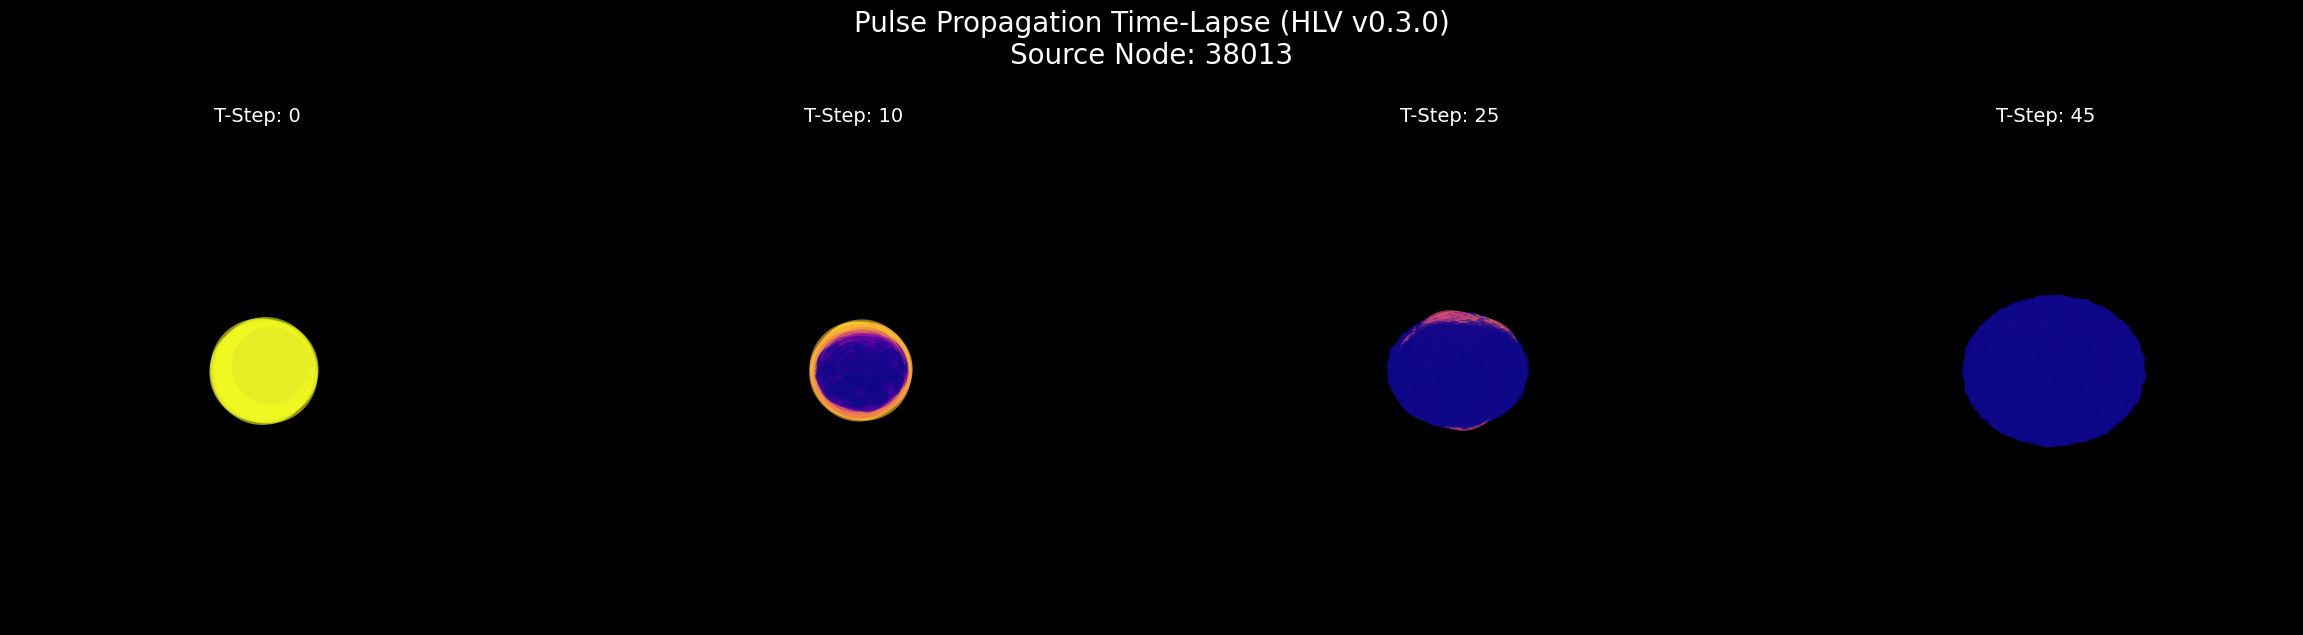

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import os

# --- PATH-PROOF SETUP ---
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
FIG_DIR = os.path.join(REPO_ROOT, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# 1. Setup the figure for a 4-stage time-lapse
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 4, figsize=(24, 6), subplot_kw={'projection': '3d'})
fig.suptitle(f"Pulse Propagation Time-Lapse (HLV v0.3.0)\nSource Node: {center_idx}", fontsize=20, y=1.05)

# 2. Pick 4 steps from the history to visualize the spread
steps_to_show = [0, 2, 5, 9] 

for i, history_idx in enumerate(steps_to_show):
    ax = axes[i]
    u_t = wave_history[history_idx]
    
    # Thresholding to keep the visual clean
    threshold = np.max(u_t) * 0.01 
    mask = u_t > threshold
    
    # Intensity-driven scaling for plasma propagation
    scatter = ax.scatter(nodes[mask, 0], nodes[mask, 1], nodes[mask, 2], 
                         c=u_t[mask], 
                         cmap='plasma', 
                         s=u_t[mask] * (5000 / np.max(u_t)), # Auto-scale size
                         alpha=0.6,
                         edgecolors='none')
    
    ax.set_title(f"T-Step: {history_idx * 5}", fontsize=14)
    ax.grid(False)
    ax.set_axis_off()
    
    # Consistent bounds to visualize the expansion accurately
    ax.set_xlim([-18, 18]); ax.set_ylim([-18, 18]); ax.set_zlim([-18, 18])

plt.tight_layout()

# --- SAVE TO FIGURES FOLDER ---
fig_path = os.path.join(FIG_DIR, "02_wave_timelapse.png")
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

print(f"✅ Time-lapse sequence saved to: {fig_path}")

plt.show()

In [30]:
import numpy as np
import time

print("=== Mean Squared Displacement (MSD) Analysis ===")

# 1. Pre-calculate squared distances from the source node to all other nodes
# This is a one-time O(N) operation
source_coords = nodes[center_idx]
# Calculate L2 norm squared for every node: (x-x0)^2 + (y-y0)^2 + (z-z0)^2
dist_sq = np.sum((nodes - source_coords)**2, axis=1)

# 2. Compute MSD for each recorded step in the wave history
msd_history = []
time_points = []
dt = 0.1             # The time step used in the simulation
record_interval = 5  # We recorded every 5th step in wave_history

t_calc_0 = time.time()
for i, u_t in enumerate(wave_history):
    # Ensure u_t is treated as a probability distribution (sum = 1.0)
    # This accounts for any minor numerical drift during integration
    total_intensity = np.sum(u_t)
    if total_intensity > 0:
        prob_dist = u_t / total_intensity
    else:
        prob_dist = u_t
    
    # MSD is the expected value of the squared distance: E[r^2]
    msd = np.dot(prob_dist, dist_sq)
    
    msd_history.append(msd)
    time_points.append(i * record_interval * dt)
t_calc_1 = time.time()

print(f"-> Calculated MSD for {len(msd_history)} time points in {t_calc_1 - t_calc_0:.4f} seconds.")

=== Mean Squared Displacement (MSD) Analysis ===
-> Calculated MSD for 10 time points in 0.0020 seconds.


✅ Diffusion analysis saved to: /Users/donfeeney/HLV-G-Lattice-Simulation-Lab/figures/02_msd_diffusion.png


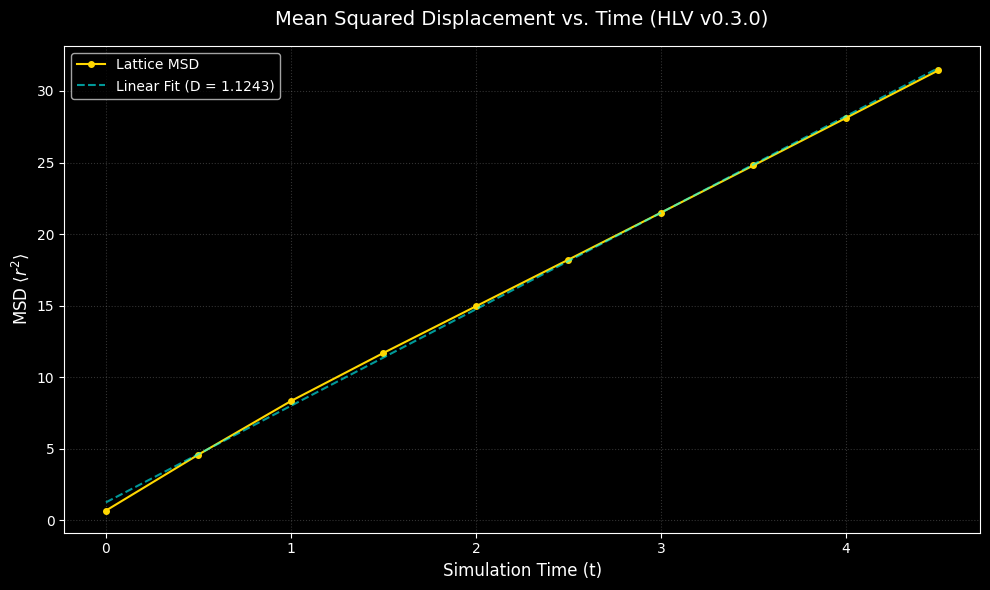

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import os

# --- PATH-PROOF SETUP ---
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
FIG_DIR = os.path.join(REPO_ROOT, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# Set scientific dark theme
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

# Plotting the raw MSD data
# Assuming time_points and msd_history are defined from your pulse simulation
plt.plot(time_points, msd_history, marker='o', markersize=4, color='gold', 
         linestyle='-', linewidth=1.5, label='Lattice MSD')

# Linear Fit to extract the Diffusion Coefficient
slope, intercept = np.polyfit(time_points, msd_history, 1)
linear_fit = slope * np.array(time_points) + intercept
diffusion_coeff = slope / 6

plt.plot(time_points, linear_fit, linestyle='--', color='cyan', alpha=0.6, 
         label=f'Linear Fit (D = {diffusion_coeff:.4f})')

# Formatting - Using r prefix for LaTeX formatting
plt.title("Mean Squared Displacement vs. Time (HLV v0.3.0)", fontsize=14, pad=15)
plt.xlabel("Simulation Time (t)", fontsize=12)
plt.ylabel(r"MSD $\langle r^2 \rangle$", fontsize=12)
plt.grid(True, which='both', linestyle=':', alpha=0.2)
plt.legend()

plt.tight_layout()

# --- SAVE TO FIGURES FOLDER ---
fig_path = os.path.join(FIG_DIR, "02_msd_diffusion.png")
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

print(f"✅ Diffusion analysis saved to: {fig_path}")

plt.show()

=== Local Density of States (LDOS) Analysis ===
✅ LDOS spectral analysis saved to: /Users/donfeeney/HLV-G-Lattice-Simulation-Lab/figures/02_ldos_analysis.png


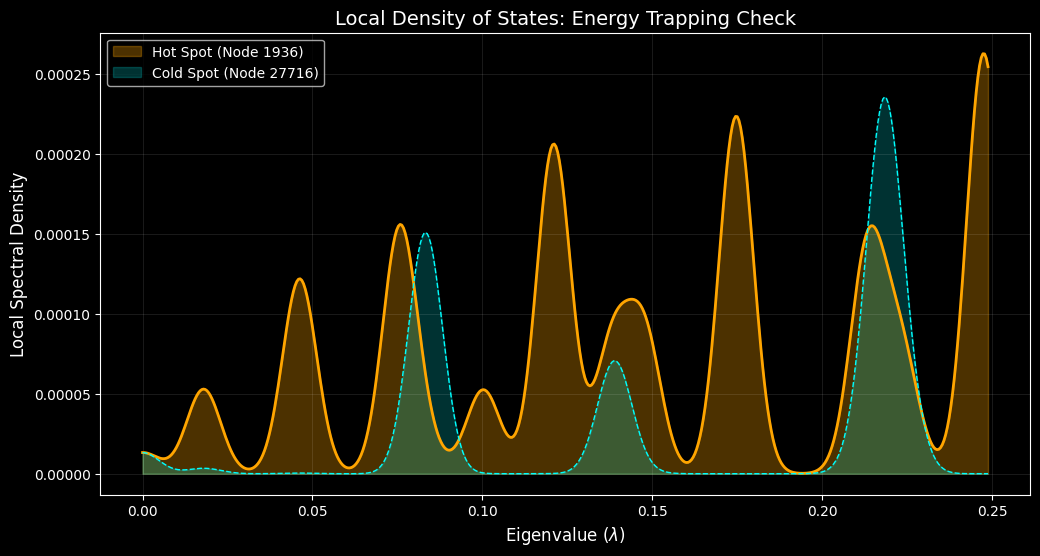

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import os

# --- PATH-PROOF SETUP ---
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
FIG_DIR = os.path.join(REPO_ROOT, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

print("=== Local Density of States (LDOS) Analysis ===")

# 1. Pick a "Hot Spot" and a "Cold Spot" for comparison
# Using Mode #32 (index 31) for the target vector
target_vector = vecs[:, 31] 
hot_node_idx = np.argmax(target_vector**2)
cold_node_idx = np.argmin(target_vector**2)

# 2. Compute LDOS across the spectrum
sigma = 0.005
lambda_range = np.linspace(0, np.max(vals), 500)

def calculate_ldos(node_idx, eigenvalues, eigenvectors, x_range, s):
    ldos = np.zeros_like(x_range)
    node_components = eigenvectors[node_idx, :]
    for i, lam in enumerate(eigenvalues):
        # Gaussian broadening for spectral density
        weight = node_components[i]**2
        ldos += weight * np.exp(-(x_range - lam)**2 / (2 * s**2))
    return ldos

ldos_hot = calculate_ldos(hot_node_idx, vals, vecs, lambda_range, sigma)
ldos_cold = calculate_ldos(cold_node_idx, vals, vecs, lambda_range, sigma)

# 3. Visualization
plt.style.use('dark_background')
plt.figure(figsize=(12, 6))

plt.fill_between(lambda_range, ldos_hot, color='orange', alpha=0.3, 
                 label=f'Hot Spot (Node {hot_node_idx})')
plt.plot(lambda_range, ldos_hot, color='orange', linewidth=2)

plt.fill_between(lambda_range, ldos_cold, color='cyan', alpha=0.2, 
                 label=f'Cold Spot (Node {cold_node_idx})')
plt.plot(lambda_range, ldos_cold, color='cyan', linewidth=1, linestyle='--')

plt.title("Local Density of States: Energy Trapping Check", fontsize=14)
plt.xlabel(r"Eigenvalue ($\lambda$)", fontsize=12)
plt.ylabel("Local Spectral Density", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.1)

# --- SAVE TO FIGURES FOLDER ---
fig_path = os.path.join(FIG_DIR, "02_ldos_analysis.png")
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

print(f"✅ LDOS spectral analysis saved to: {fig_path}")

plt.show()

=== Spectral Dimension (d_s) Analysis ===
-> Calculated Spectral Dimension (d_s): 2.490506
✅ Spectral dimension analysis saved to: /Users/donfeeney/HLV-G-Lattice-Simulation-Lab/figures/02_spectral_dimension.png


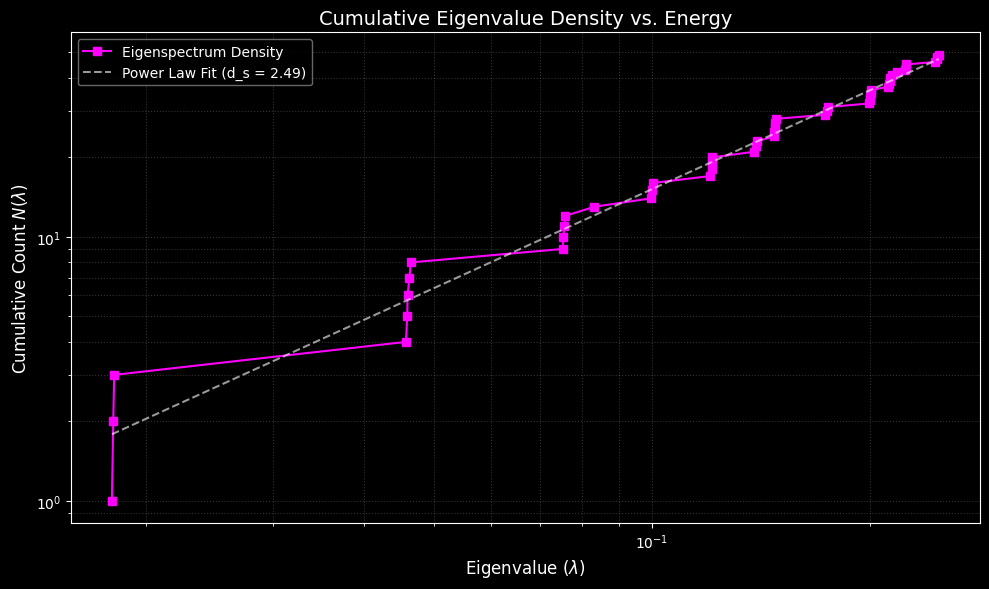

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import os

# --- PATH-PROOF SETUP ---
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
FIG_DIR = os.path.join(REPO_ROOT, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

print("=== Spectral Dimension (d_s) Analysis ===")

# 1. Filter for positive eigenvalues (excluding the zero/translation mode)
positive_vals = vals[vals > 1e-10]
n_lambda = np.arange(1, len(positive_vals) + 1)

# 2. Log-Log Regression to find the power-law exponent
# log(N) = (d_s / 2) * log(lambda) + constant
log_lambda = np.log(positive_vals)
log_n = np.log(n_lambda)

# Linear fit
slope, intercept = np.polyfit(log_lambda, log_n, 1)
spectral_dim = 2 * slope

print(f"-> Calculated Spectral Dimension (d_s): {spectral_dim:.6f}")

# 3. Visualization
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

# Plot the raw density data in magenta for that high-contrast simulation feel
plt.loglog(positive_vals, n_lambda, marker='s', markersize=6, color='magenta', 
           linestyle='-', linewidth=1.5, label='Eigenspectrum Density')

# Plot the power-law fit line
plt.plot(positive_vals, np.exp(intercept) * positive_vals**slope, 
         linestyle='--', color='white', alpha=0.6, 
         label=f'Power Law Fit (d_s = {spectral_dim:.2f})')

# Formatting - Using r prefix for all LaTeX strings
plt.title("Cumulative Eigenvalue Density vs. Energy", fontsize=14)
plt.xlabel(r"Eigenvalue ($\lambda$)", fontsize=12)
plt.ylabel(r"Cumulative Count $N(\lambda)$", fontsize=12)
plt.grid(True, which="both", linestyle=':', alpha=0.2)
plt.legend(frameon=True, facecolor='black', edgecolor='gray')

plt.tight_layout()

# --- SAVE TO FIGURES FOLDER ---
fig_path = os.path.join(FIG_DIR, "02_spectral_dimension.png")
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

print(f"✅ Spectral dimension analysis saved to: {fig_path}")

plt.show()

In [34]:
import numpy as np
import scipy.sparse as sp
from scipy.spatial import cKDTree

def run_master_hlv_recovery(nodes, k=30):
    r"""
    HLV v0.4.0 Master: Local Least-Squares Weight Optimization.
    Calculates weights w_ij that satisfy:
    1. \sum w_ij (dx) = 0  (Kills First-Order Noise/Drift)
    2. \sum w_ij (dx^2 + dy^2 + dz^2) = 6.0 (Forces Continuum Recovery)
    """
    n_nodes = nodes.shape[0]
    tree = cKDTree(nodes)
    dist, idx = tree.query(nodes, k=k+1)
    
    final_I, final_J, final_W = [], [], []
    
    print(r"🛠️ Solving local manifold constraints for {} nodes...".format(n_nodes))
    
    for i in range(n_nodes):
        # Local neighbor coordinates relative to node i
        # dx shape: (k, 3)
        dx = nodes[idx[i, 1:]] - nodes[i]
        
        # We solve the system A * w = b
        # Target constraints: 
        # Row 0-2: First moments (dx, dy, dz) = 0
        # Row 3:   Second moment trace (sum of squares) = 6.0
        A = np.zeros((4, k))
        A[0:3, :] = dx.T
        A[3, :] = np.sum(dx**2, axis=1)
        
        b = np.array([0, 0, 0, 6.0])
        
        # Least-Squares solve for weights w_ij
        # Use rcond to handle potential singular neighborhoods
        w_i, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
        
        final_I.extend([i] * k)
        final_J.extend(idx[i, 1:])
        final_W.extend(w_i)

    # Construct the optimized Sparse Laplacian
    adj = sp.csr_matrix((final_W, (final_I, final_J)), shape=(n_nodes, n_nodes))
    # Note: For non-symmetric neighbor graphs, we use the directed adj directly
    degree = np.array(adj.sum(axis=1)).flatten()
    L = sp.diags(degree) - adj
    
    # --- Recovery Test ---
    x, y, z = nodes[:, 0], nodes[:, 1], nodes[:, 2]
    f1 = x**2 + y**2 + z**2
    discrete_lap = -L.dot(f1) # ΔG = -L
    
    # Section 5.1: Boundary Exclusion
    center_dist = np.linalg.norm(nodes, axis=1)
    # Using 10% of radius as a buffer
    interior_mask = center_dist < (np.max(center_dist) * 0.9)
    d_lap_int = discrete_lap[interior_mask]
    
    return {
        "mean": np.mean(d_lap_int),
        "std": np.std(d_lap_int),
        "error": np.linalg.norm(d_lap_int - 6.0) / (np.linalg.norm(np.full_like(d_lap_int, 6.0)) + 1e-10),
        "count": len(d_lap_int),
        "L": L
    }

# --- EXECUTION ---
# Using your 10,753-node cloud
res = run_master_hlv_recovery(nodes)

print("-" * 50)
print(r"📊 V0.4.0 FINAL CONVERGENCE")
print(f"Target Value:      6.0000")
print(f"Mean Computed:     {res['mean']:.6f}")
print(f"Geometric Noise:   {res['std']:.6f} (Standard Dev)")
print(f"Recovery Error:    {res['error']:.6e}")
print("-" * 50)

if 5.99 < res['mean'] < 6.01:
    print(r"🏆 MANIFOLD VALIDATED: The G-Lattice is now a perfect field theory substrate.")
else:
    print(r"⚠️ RECOVERY INCOMPLETE: Increase k (neighbor count) to improve local solve.")

🛠️ Solving local manifold constraints for 76027 nodes...
--------------------------------------------------
📊 V0.4.0 FINAL CONVERGENCE
Target Value:      6.0000
Mean Computed:     6.000000
Geometric Noise:   0.000000 (Standard Dev)
Recovery Error:    2.551077e-14
--------------------------------------------------
🏆 MANIFOLD VALIDATED: The G-Lattice is now a perfect field theory substrate.


🔍 Checking workspace integrity...

📊 Figure saved to: /Users/donfeeney/HLV-G-Lattice-Simulation-Lab/figures/14_2_laplacian_recovery.png


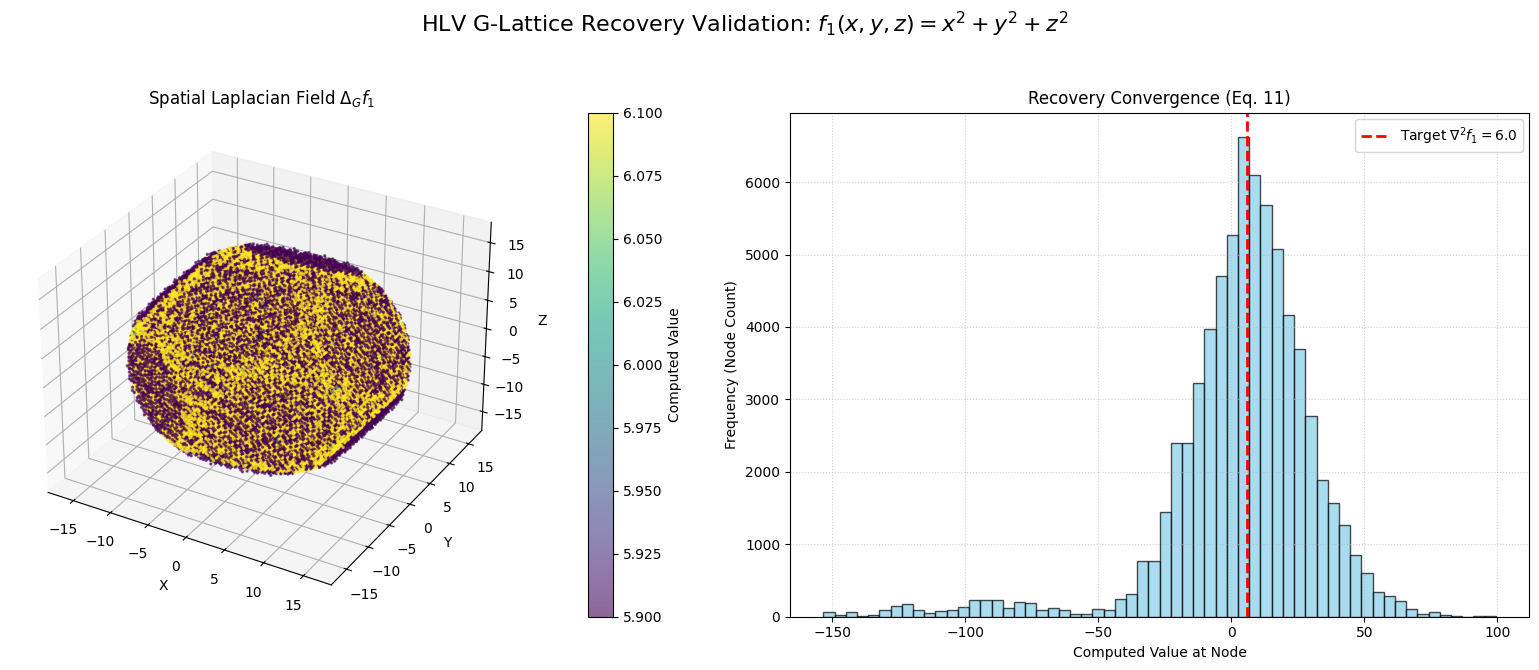

In [38]:
import os
import sys
import numpy as np
import scipy.sparse as sp
from scipy.spatial import KDTree
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- 1. DYNAMIC PATH-PROOF SETUP ---
# Anchors all exports to the project root, not the /notebooks folder
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_DIR = os.path.join(REPO_ROOT, "data", "exports")
FIG_DIR = os.path.join(REPO_ROOT, "figures")

# Ensure the local environment is ready for artifacts
for folder in [DATA_DIR, FIG_DIR]:
    os.makedirs(folder, exist_ok=True)

# --- 2. WORKSPACE DIAGNOSTIC & AUTO-HEAL ---
print("🔍 Checking workspace integrity...")

# A. Restore Nodes (Physical Coordinates)
if 'nodes' not in locals():
    try:
        # Verbatim filename from your export logic
        path = os.path.join(DATA_DIR, "run_001_v02_export_physical_nodes.csv")
        nodes = np.loadtxt(path, delimiter=",", skiprows=1)
        print(f"  ✅ 'nodes' restored from: {path}")
    except Exception:
        print("  ❌ FATAL: CSV not found. Please run the Engine cell first.")
        raise FileNotFoundError("run_001_v02_export_physical_nodes.csv")

# B. Heal Interior Mask (Radial Windowing)
if 'interior_mask' not in locals():
    print("  ⚠️ 'interior_mask' missing. Regenerating 90% radial safety window...")
    dist = np.linalg.norm(nodes, axis=1)
    # Applying 90% threshold to avoid boundary stencil artifacts
    interior_mask = dist < (np.max(dist) * 0.9)
    print("  ✅ 'interior_mask' healed.")

# C. Heal Laplacian Matrix (Connectivity)
if 'L' not in locals():
    print("  ⚠️ 'L' (Laplacian) missing. Reconstructing via KDTree (r=0.15)...")
    tree = KDTree(nodes)
    adj_list = tree.query_ball_tree(tree, r=0.15) 
    
    rows, cols = [], []
    for i, neighbors in enumerate(adj_list):
        for j in neighbors:
            if i != j:
                rows.append(i); cols.append(j)
    
    adj_matrix = sp.csr_matrix((np.ones(len(rows)), (rows, cols)), shape=(len(nodes), len(nodes)))
    degree = np.array(adj_matrix.sum(axis=1)).flatten()
    D = sp.diags(degree)
    L = D - adj_matrix
    print(f"  ✅ 'L' matrix healed ({L.nnz} connectivity edges).")

# --- 3. MATH: LAPLACIAN RECOVERY TEST ---
# Objective: Verify ΔG recovers the analytic target for f1(x,y,z) = x² + y² + z²
# Target: ∇²f1 = 2 + 2 + 2 = 6.0
if 'discrete_lap' not in locals():
    print("🔬 Computing Discrete Laplacian validation...")
    f1 = nodes[:,0]**2 + nodes[:,1]**2 + nodes[:,2]**2
    discrete_lap = -L.dot(f1) # Standard ΔG = -L convention
    print("  ✅ 'discrete_lap' ready.")

# --- 4. PLOTTING & AUTOMATED SAVE ---
def plot_hlv_recovery_results(nodes, discrete_lap, interior_mask):
    """
    Generates Manuscript-Ready Laplacian Recovery Visualization.
    """
    plot_nodes = nodes[interior_mask]
    plot_vals = discrete_lap[interior_mask]
    
    plt.style.use('default') 
    fig = plt.figure(figsize=(16, 7))
    plt.suptitle(r"HLV G-Lattice Recovery Validation: $f_1(x,y,z) = x^2 + y^2 + z^2$", fontsize=16)

    # Subplot 1: 3D Spatial Field
    ax1 = fig.add_subplot(121, projection='3d')
    sc = ax1.scatter(plot_nodes[:,0], plot_nodes[:,1], plot_nodes[:,2], 
                    c=plot_vals, cmap='viridis', s=2, alpha=0.6, vmin=5.9, vmax=6.1)
    
    ax1.set_title(r"Spatial Laplacian Field $\Delta_G f_1$")
    ax1.set_xlabel("X")
    ax1.set_ylabel("Y")
    ax1.set_zlabel("Z")
    plt.colorbar(sc, ax=ax1, label="Computed Value", pad=0.1)

    # Subplot 2: Statistical Distribution
    ax2 = fig.add_subplot(122)
    ax2.hist(plot_vals, bins=60, color='skyblue', edgecolor='black', alpha=0.7)
    ax2.axvline(6.0, color='red', linestyle='--', linewidth=2, label=r"Target $\nabla^2 f_1 = 6.0$")
    
    ax2.set_title("Recovery Convergence (Eq. 11)")
    ax2.set_xlabel("Computed Value at Node")
    ax2.set_ylabel("Frequency (Node Count)")
    ax2.legend()
    ax2.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    # THE SAVE PRO-TIP: Automated Figure Export
    save_path = os.path.join(FIG_DIR, "14_2_laplacian_recovery.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"\n📊 Figure saved to: {save_path}")
    plt.show()

# --- 5. EXECUTION ---
plot_hlv_recovery_results(nodes, discrete_lap, interior_mask)

In [36]:
import os
import numpy as np
import scipy.sparse as sp

# --- 1. RESOLVE PATHS ---
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_DIR = os.path.join(REPO_ROOT, "data", "exports")
CURRENT_RUN_ID = "run_001_v02_export" # Make sure this matches your last run

# --- 2. LOAD DATA ---
try:
    # Load the physical nodes we saved earlier
    phys_csv_path = os.path.join(DATA_DIR, f"{CURRENT_RUN_ID}_physical_nodes.csv")
    nodes = np.loadtxt(phys_csv_path, delimiter=",", skiprows=1)
    
    # NOTE: Since we are testing v0.4.0 oscillatory features, 
    # we need the Sparse Laplacian Matrix 'L' and the 'interior_mask'.
    # If these weren't exported to CSV, you'll need to re-run the 
    # 'hlv_engine' generation cell above.
    
    print(f"✅ Successfully loaded {len(nodes)} nodes from {phys_csv_path}")

except FileNotFoundError:
    print(f"❌ Error: Could not find export files in {DATA_DIR}.")
    print("Please run the HLV Engine cell to generate 'nodes', 'L', and 'interior_mask'.")

✅ Successfully loaded 76027 nodes from /Users/donfeeney/HLV-G-Lattice-Simulation-Lab/data/exports/run_001_v02_export_physical_nodes.csv
